In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
ZIP = "/content/drive/MyDrive/AquaSense_S4_Colab.zip"  # ajuste le chemin si besoin

!unzip -o -q "{ZIP}" -d /content/
%cd /content/AquaSense_S4_Colab
!ls -la data/cleaned/train_clean.csv

/content/AquaSense_S4_Colab
-rw-r--r-- 1 root root 16353177 Jun 18 22:22 data/cleaned/train_clean.csv


In [3]:
%pip install -q --upgrade "numpy>=2.0" "pandas>=2.2.2" scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 5.8 MB/s eta 0:00:00


In [4]:
⚠️ **Runtime → Restart session**
Puis ré-exécute les cellules **1, 2, 5, 6, 7…** (pas la cellule 3 sauf si erreur import).

SyntaxError: invalid character '⚠' (U+26A0) (1710334339.py, line 1)

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf

print("numpy  :", np.__version__)   # doit être 2.x
print("pandas :", pd.__version__)   # doit être 2.2.x
print("tf     :", tf.__version__)
print("GPU    :", tf.config.list_physical_devices("GPU"))

numpy  : 2.4.6
pandas : 3.0.3
tf     : 2.20.0
GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

PROJECT_ROOT = Path("/content/AquaSense_S4_Colab")
sys.path.insert(0, str(PROJECT_ROOT))

from src.dl_utils import (
    MODELS_DIR,
    build_mlp,
    compile_model,
    evaluate_keras_model,
    load_clean_train,
    prepare_dl_data,
    split_xy,
    train_keras_model,
)
from src.train import CLASS_ORDER, NEEDS_REPAIR

sns.set_theme(style="whitegrid")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT OK :", PROJECT_ROOT)

PROJECT_ROOT OK : /content/AquaSense_S4_Colab


In [7]:
df = load_clean_train()
X_raw, y_raw = split_xy(df)

print("Shape X :", X_raw.shape)
print("Distribution cible (%) :")
print(y_raw.value_counts(normalize=True).mul(100).round(1))

le = LabelEncoder()
le.fit(CLASS_ORDER)
print("\nEncodage y : 0=functional, 1=needs repair, 2=non functional")

Shape X : (59400, 34)
Distribution cible (%) :
status_group
functional                 54.3
non functional             38.4
functional needs repair     7.3
Name: proportion, dtype: float64

Encodage y : 0=functional, 1=needs repair, 2=non functional


In [8]:
data = prepare_dl_data(test_size=0.2)

print("X_train :", data["X_train"].shape)
print("X_val   :", data["X_val"].shape)
print("Class weights :", data["class_weight"])

X_train : (47520, 64)
X_val   : (11880, 64)
Class weights : {0: 0.6137869570271631, 1: 4.585987261146497, 2: 0.867517388685032}


In [9]:
mlp = build_mlp(data["input_dim"], n_classes=3, dropout=0.3)
compile_model(mlp, lr=1e-3, class_weight=data["class_weight"])
mlp.summary()

history = train_keras_model(
    mlp,
    data,
    epochs=100,
    batch_size=512,
    validation_split=0.2,
    use_class_weight=True,
)

Model: "mlp_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,523 (232.51 KB)

 Trainable params: 58,755 (229.51 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.4295 - loss: 1.1180 - val_accuracy: 0.5061 - val_loss: 1.0044 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4978 - loss: 0.9995 - val_accuracy: 0.5279 - val_loss: 0.9449 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5193 - loss: 0.9659 - val_accuracy: 0.5755 - val_loss: 0.9095 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5361 - loss: 0.9353 - val_accuracy: 0.5381 - val_loss: 0.9292 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5393 - loss: 0.9256 - val_accuracy: 0.5441 - val_loss: 0.9183 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5486 - loss: 0.9113 - val_accuracy: 0.5758 - val_loss: 0.8889 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5551 - loss: 0.8981 - val_a

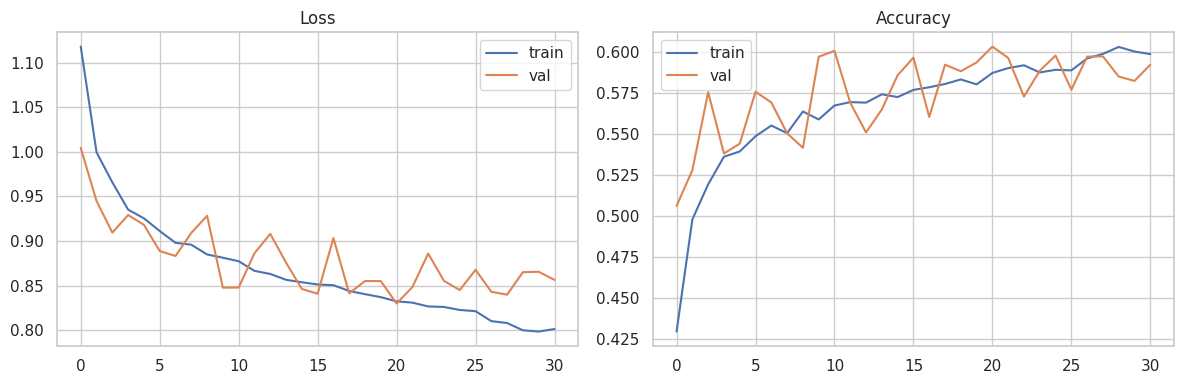

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

F1-Macro          : 0.5297
F1 needs repair   : 0.3008
Recall needs repair : 0.6037
Accuracy          : 0.5950
Objectif F1 >= 0.72 : NON

                 precision    recall  f1-score   support

    functional       0.76      0.57      0.65      6452
  needs repair       0.20      0.60      0.30       863
non functional       0.64      0.63      0.63      4565

      accuracy                           0.60     11880
     macro avg       0.54      0.60      0.53     11880
  weighted avg       0.68      0.60      0.62     11880



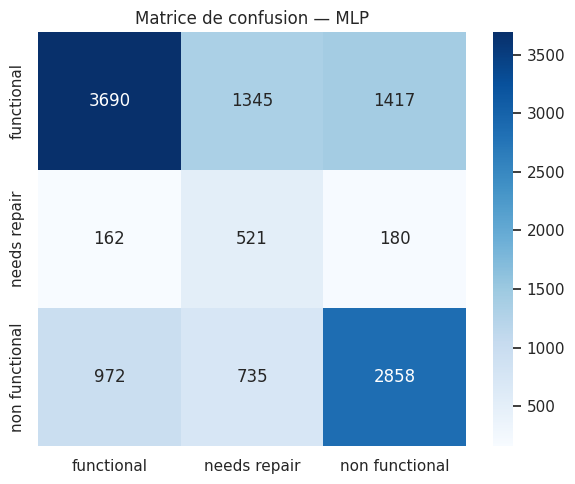

Modèle sauvegardé → /content/AquaSense_S4_Colab/models/mlp_best_v1.keras


In [11]:
metrics = evaluate_keras_model(mlp, data["X_val"], data["y_val"], data["label_encoder"])

print(f"F1-Macro          : {metrics['f1_macro']:.4f}")
print(f"F1 needs repair   : {metrics['f1_needs_repair']:.4f}")
print(f"Recall needs repair : {metrics['recall_needs_repair']:.4f}")
print(f"Accuracy          : {metrics['accuracy']:.4f}")
print(f"Objectif F1 >= 0.72 : {'OK' if metrics['f1_macro'] >= 0.72 else 'NON'}")

print("\n", classification_report(
    data["y_val"], metrics["y_pred"],
    target_names=["functional", "needs repair", "non functional"],
))

cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["functional", "needs repair", "non functional"],
    yticklabels=["functional", "needs repair", "non functional"],
    ax=ax,
)
ax.set_title("Matrice de confusion — MLP")
plt.tight_layout()
plt.show()

save_path = MODELS_DIR / "mlp_best_v1.keras"
mlp.save(save_path)
print(f"Modèle sauvegardé → {save_path}")

In [12]:
!cp /content/AquaSense_S4_Colab/models/mlp_best_v1.keras /content/drive/MyDrive/
print("Copié sur Drive → MyDrive/mlp_best_v1.keras")

Copié sur Drive → MyDrive/mlp_best_v1.keras
